# **XGBosst Model - Backtesting for (24hr ahead) forecasting**

## **1) Data Loading**

In [15]:
# Loading the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [16]:
df = pd.read_parquet("nrldc_cleaned.parquet")
df.columns = ["load"]
df = df.sort_index()

## **2) Train-Test Split**

In [17]:
cutoff = df.index[-1] - pd.DateOffset(months=3)

train = df[df.index < cutoff]
test  = df[df.index >= cutoff]

print("Train rows:", len(train))
print("Test rows :", len(test))

Train rows: 50399
Test rows : 8545


## **3) Feature Engineering**

In [18]:
def create_features(data, full_series):

    df = data.copy()

    # Lag features
    df["lag1"] = full_series.shift(1).loc[df.index]
    df["lag2"] = full_series.shift(2).loc[df.index]
    df["lag96"] = full_series.shift(96).loc[df.index]
    df["lag192"] = full_series.shift(192).loc[df.index]

    # Rolling features
    s = full_series.shift(1)

    df["rolling_mean_4"] = s.rolling(4).mean().loc[df.index]
    df["rolling_mean_12"] = s.rolling(12).mean().loc[df.index]

    # Time features
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"] = df.index.month

    return df.dropna()

## **4) Prepare Training Data**

In [19]:
train_feat = create_features(train, df["load"])

X_train = train_feat.drop("load", axis=1)
y_train = train_feat["load"]

FEATURE_COLS = X_train.columns

print("Feature columns:")
print(FEATURE_COLS)

Feature columns:
Index(['lag1', 'lag2', 'lag96', 'lag192', 'rolling_mean_4', 'rolling_mean_12',
       'hour', 'dayofweek', 'month'],
      dtype='object')


## **5) Train XGBoost Model**

In [20]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## **6) Forecast Function**

In [21]:
def forecast(start_idx, series, steps):

    buffer = list(series.iloc[start_idx-300:start_idx])
    preds = []

    for i in range(steps):

        next_time = series.index[start_idx] + pd.Timedelta(minutes=15*i)

        row = {
            "lag1": buffer[-1],
            "lag2": buffer[-2],
            "lag96": buffer[-96],
            "lag192": buffer[-192],
            "rolling_mean_4": np.mean(buffer[-4:]),
            "rolling_mean_12": np.mean(buffer[-12:]),
            "hour": next_time.hour,
            "dayofweek": next_time.dayofweek,
            "month": next_time.month
        }

        pred = model.predict(pd.DataFrame([row])[FEATURE_COLS])[0]

        preds.append(pred)
        buffer.append(pred)

    actual = series.iloc[start_idx:start_idx+steps].values

    return np.array(preds), actual

## **7) Setup Backtesting**

In [22]:
series = df["load"]

start = series.index.get_loc(test.index[0])

horizons = {
    "24h": 96,
    "48h": 192,
    "72h": 288
}

## **8) Run Backtest**


===== 24h Forecast =====


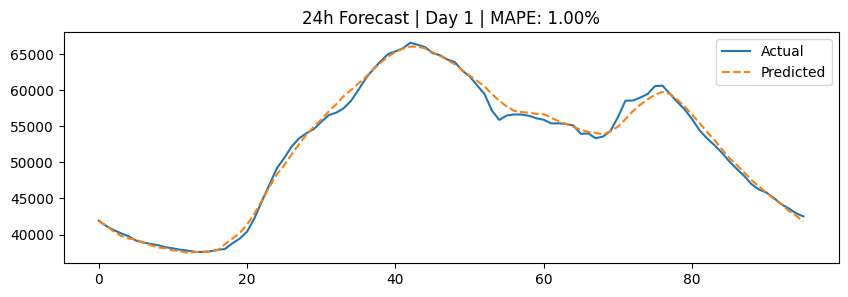

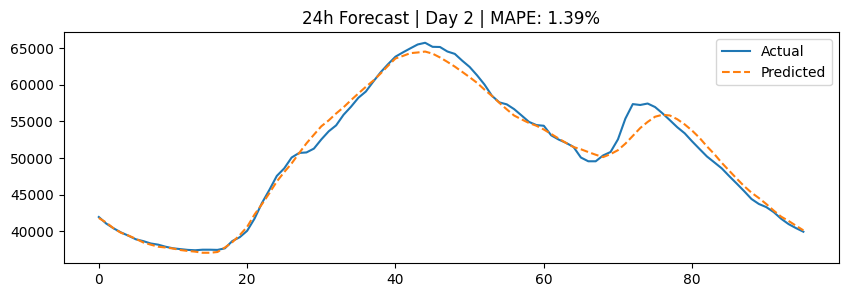

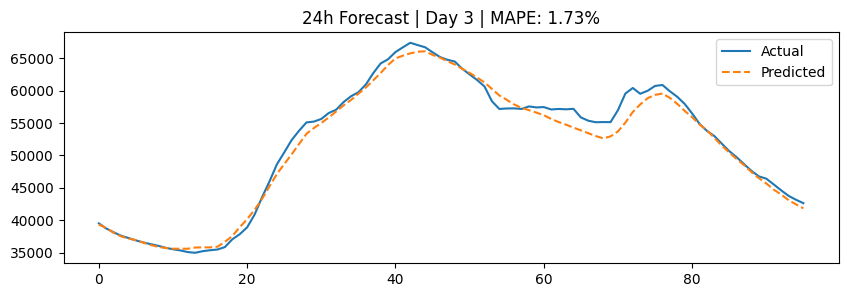

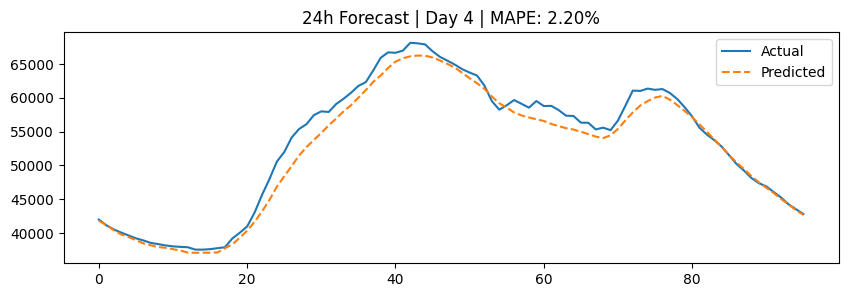

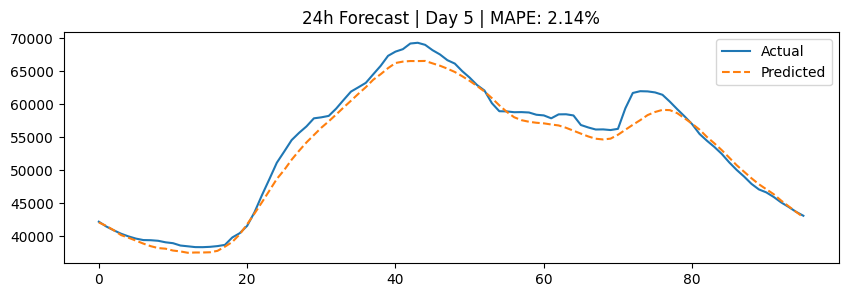


Backtest Summary
   Day          MAE         RMSE  MAPE (%)
0    1   529.663883   746.831510  1.002510
1    2   738.460384  1055.619958  1.388366
2    3   933.958382  1269.910695  1.733779
3    4  1224.179647  1614.661627  2.199055
4    5  1198.135132  1539.601057  2.137173

===== 48h Forecast =====


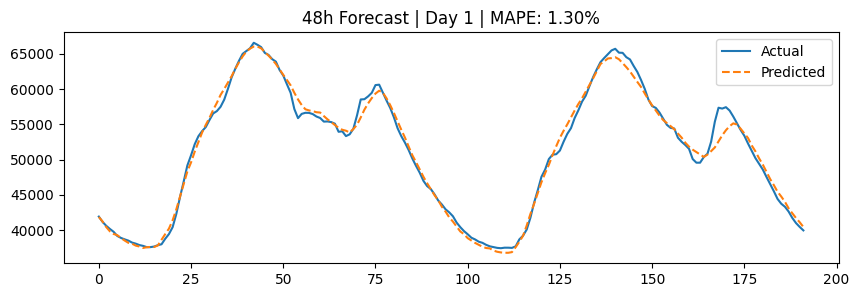

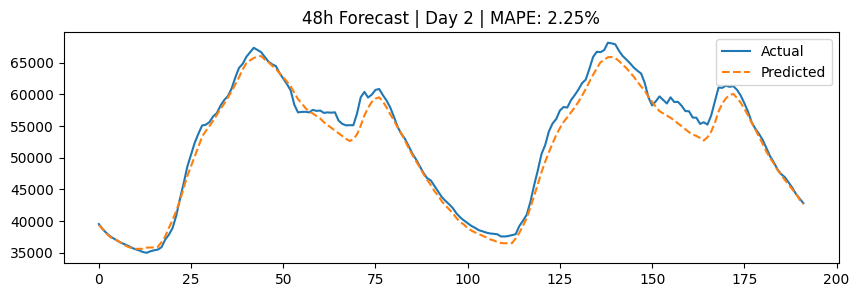

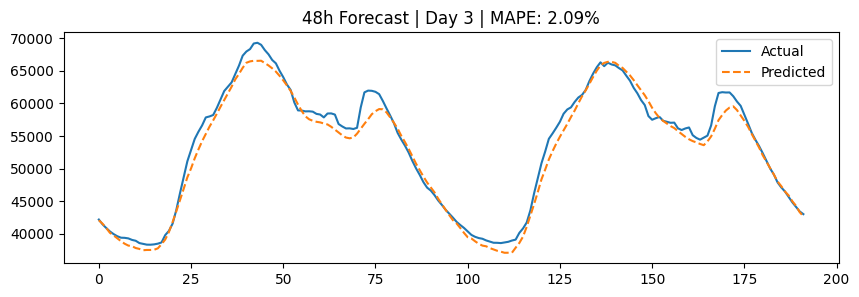

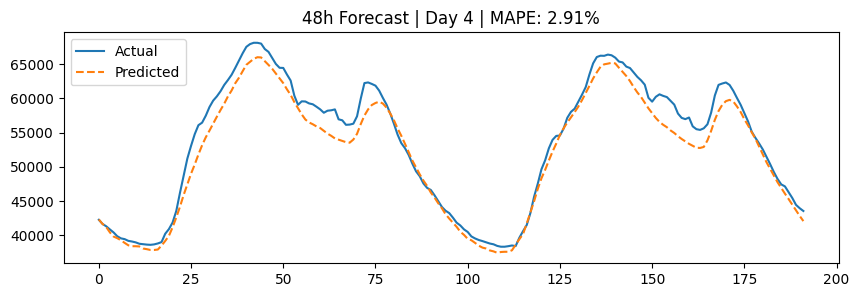

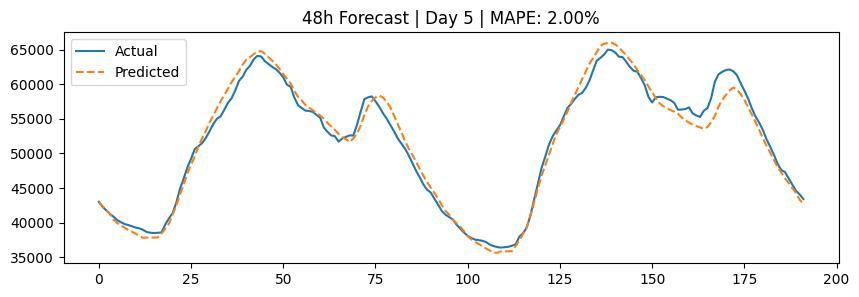


Backtest Summary
   Day          MAE         RMSE  MAPE (%)
0    1   673.999268   960.519195  1.298112
1    2  1231.414567  1566.752963  2.254654
2    3  1132.213346  1468.529457  2.086437
3    4  1634.901522  2026.955388  2.908137
4    5  1068.936816  1337.296612  2.001349

===== 72h Forecast =====


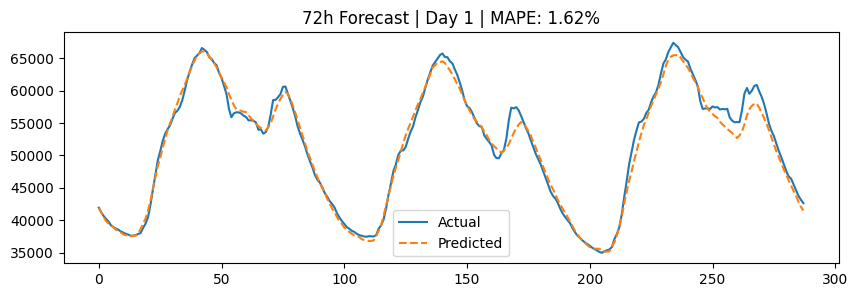

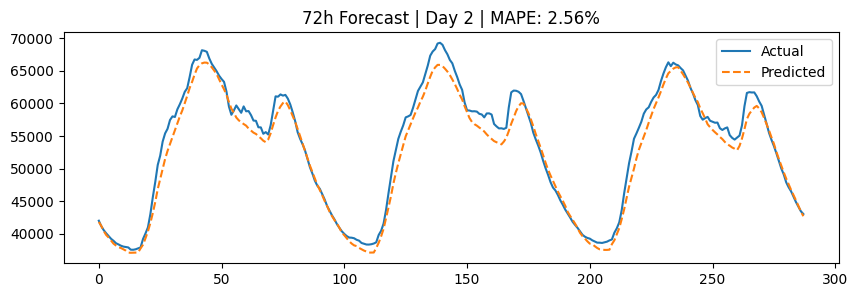

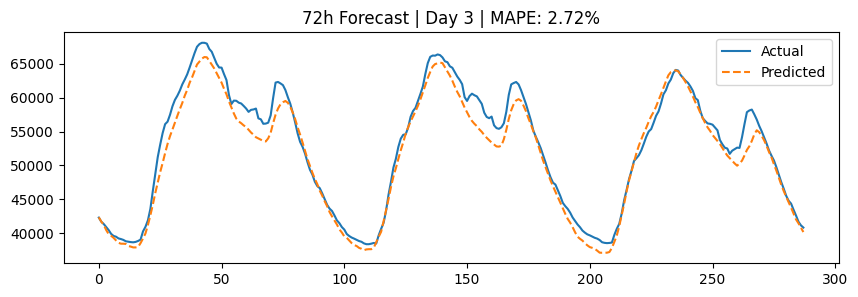

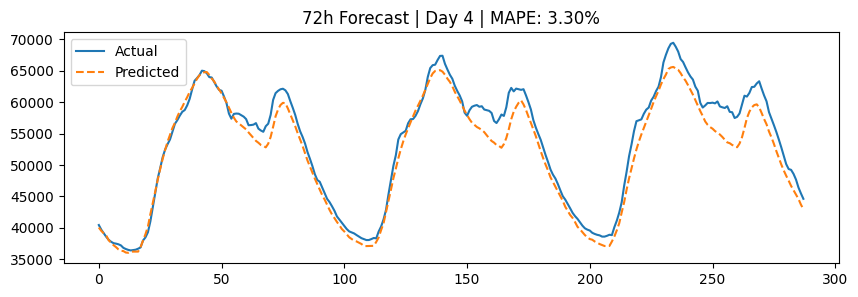

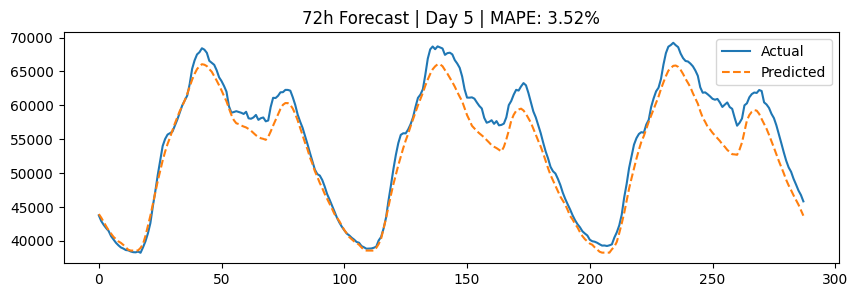


Backtest Summary
   Day          MAE         RMSE  MAPE (%)
0    1   863.115782  1217.364708  1.617124
1    2  1416.070158  1804.290976  2.558991
2    3  1479.646102  1889.650143  2.719580
3    4  1820.486260  2271.143188  3.303534
4    5  2037.026717  2528.298255  3.517069


In [23]:
summary_results = []

for name, steps in horizons.items():

    print(f"\n===== {name} Forecast =====")

    results = []

    for i in range(5):

        idx = start + i * steps

        preds, actual = forecast(idx, series, steps)

        mae = mean_absolute_error(actual, preds)
        rmse = np.sqrt(mean_squared_error(actual, preds))
        mape = np.mean(np.abs((actual - preds) / actual)) * 100

        results.append([i+1, mae, rmse, mape])

        plt.figure(figsize=(10,3))
        plt.plot(actual, label="Actual")
        plt.plot(preds, "--", label="Predicted")
        plt.title(f"{name} Forecast | Day {i+1} | MAPE: {mape:.2f}%")
        plt.legend()
        plt.show()

    res = pd.DataFrame(results, columns=["Day","MAE","RMSE","MAPE (%)"])

    avg_mae = res["MAE"].mean()
    avg_rmse = res["RMSE"].mean()
    avg_mape = res["MAPE (%)"].mean()

    print("\nBacktest Summary")
    print(res)

    summary_results.append([name, avg_mae, avg_rmse, avg_mape])

## **9) Model Comparison**

In [24]:
final = pd.DataFrame(summary_results,
                     columns=["Horizon","Avg MAE","Avg RMSE","Avg MAPE (%)"])

print("\n==============================")
print("FORECAST HORIZON COMPARISON")
print("==============================")

print(final)


FORECAST HORIZON COMPARISON
  Horizon      Avg MAE     Avg RMSE  Avg MAPE (%)
0     24h   924.879486  1245.324969      1.692176
1     48h  1148.293104  1472.010723      2.109738
2     72h  1523.269004  1942.149454      2.743260


## **Executive Summary — XGBoost Forecasting Model**

---

* **Objective:**
  Implement an **XGBoost-based time series forecasting model** to generate accurate multi-horizon electricity load predictions for the NRLDC power grid.

* **Model Approach:**

  * Gradient boosted tree model (**XGBoost**) trained using engineered time-series features including **lag variables, rolling statistics, and calendar features**.
  * Forecasts generated using **recursive multi-step prediction**, enabling day-ahead and multi-day load forecasting.

* **Forecast Horizon Evaluation:**

  | Horizon           | MAE (MW) | RMSE (MW) | MAPE      |
  | ----------------- | -------- | --------- | --------- |
  | **24-hour ahead** | 924.88   | 1245.32   | **1.69%** |
  | **48-hour ahead** | 1148.29  | 1472.01   | **2.11%** |
  | **72-hour ahead** | 1523.27  | 1942.15   | **2.74%** |

* **Key Observations:**

  * Forecasting error **gradually increases with prediction horizon**, which is expected in recursive time-series forecasting due to error propagation.
  * Despite the increasing horizon, **MAPE remains below 3% even for 72-hour forecasts**, indicating strong predictive performance.

* **Operational Performance:**

  * **24-hour ahead forecasting achieves ~1.7% MAPE**, demonstrating **high accuracy for day-ahead load prediction**.
  * The model successfully captures **daily demand cycles and load variability** within the NRLDC grid.

* **Model Stability:**

  * Error growth across horizons remains **smooth and controlled**, suggesting the model is **stable and not prone to forecast divergence**.

* **Conclusion:**

  * The XGBoost model provides **reliable multi-horizon electricity load forecasts**, making it suitable for **operational day-ahead and short-term grid demand prediction**.

* **Future Improvements:**

  * Incorporate **weather variables (temperature, humidity)** to improve peak load prediction.
  * Explore **advanced architectures such as LSTM or Temporal Fusion Transformers** for further accuracy improvements.
